<a href="https://colab.research.google.com/github/lohaniSatwik/steam-games-data-mining/blob/master/Code/section4e_knn_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 4e — K-Nearest Neighbours
**IE500 Data Mining | Team 9 – Brewed Clusters**

> **Google Colab notebook.** Run all cells top to bottom.

### Setup
- Model: `KNeighborsClassifier` — classifies by majority vote among the k closest training samples
- Continuous columns are **already StandardScaled** — KNN is distance-based so scaling matters
- **Imbalance:** KNN has **no `class_weight` parameter**. Class imbalance is a known limitation — the majority class (Good, 63%) dominates neighbourhood votes. This is noted as a limitation in the results.
- **Outer CV:** 5-fold stratified (unbiased performance estimate)
- **Inner CV:** 3-fold `GridSearchCV` over `n_neighbors`, `weights`, `metric`
- **Metric:** Macro F1 (primary), per-class F1 (secondary)
- **Baselines to beat:** LR = 0.4355 | SVM = 0.4693

> **Note on subsampling:** KNN requires computing distances to every training point at prediction time.  
> At 45K samples × 147 features this is prohibitively slow on Colab.  
> We use a **stratified 15K subsample** of the training set for CV — class proportions are preserved.  
> The final model is evaluated on the full test set.

In [1]:
import os
if not os.path.exists('steam-games-data-mining'):
    !git clone https://github.com/lohaniSatwik/steam-games-data-mining.git
else:
    !git -C steam-games-data-mining pull
DATA_DIR = 'steam-games-data-mining/Datasets'

Cloning into 'steam-games-data-mining'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 175 (delta 92), reused 106 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (175/175), 9.31 MiB | 5.57 MiB/s, done.
Resolving deltas: 100% (92/92), done.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE  = 42
CLASS_ORDER   = ['Good', 'Mixed', 'Bad']
CLASS_COLORS  = {'Good': 'steelblue', 'Mixed': 'sandybrown', 'Bad': 'salmon'}

BASELINE_LR  = 0.4355
BASELINE_SVM = 0.4693

print('Libraries loaded.')

Libraries loaded.


In [3]:
from sklearn.model_selection import train_test_split

train = pd.read_csv(f'{DATA_DIR}/train_multiclass.csv')
test  = pd.read_csv(f'{DATA_DIR}/test_multiclass.csv')

X_train_full = train.drop(columns=['label_multiclass'])
y_train_full = train['label_multiclass']
X_test        = test.drop(columns=['label_multiclass'])
y_test        = test['label_multiclass']

# Stratified 15K subsample for CV — preserves class proportions
X_train, _, y_train, _ = train_test_split(
    X_train_full, y_train_full,
    train_size=15000, stratify=y_train_full,
    random_state=RANDOM_STATE
)

print(f'Full training set : {X_train_full.shape}')
print(f'KNN subsample     : {X_train.shape}  (used for CV)')
print(f'Test set          : {X_test.shape}   (used for final evaluation)')
print('\nClass distribution (subsample):')
vc = y_train.value_counts()
for cls in CLASS_ORDER:
    print(f'  {cls:6s}: {vc[cls]:5,d}  ({vc[cls]/len(y_train)*100:.1f}%)')

Full training set : (45324, 147)
KNN subsample     : (15000, 147)  (used for CV)
Test set          : (11331, 147)   (used for final evaluation)

Class distribution (subsample):
  Good  : 9,489  (63.3%)
  Mixed : 4,247  (28.3%)
  Bad   : 1,264  (8.4%)


## Nested Cross-Validation

- **Outer loop** (5 folds) — unbiased estimate of generalisation performance
- **Inner loop** (3-fold `GridSearchCV`) — selects best `k`, weight scheme, and distance metric
- **`n_neighbors`** — number of neighbours to vote; odd numbers avoid ties
- **`weights='uniform'`** — all neighbours vote equally
- **`weights='distance'`** — closer neighbours get more vote weight (helps with imbalance slightly)
- **`metric`** — distance function: `euclidean` (straight-line) or `manhattan` (city-block)
- `algorithm='ball_tree'` — faster than brute force for high-dimensional data
- `n_jobs=-1` — parallelises distance computation across cores

Expected runtime on Colab: **~30–60 minutes**

In [4]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    'n_neighbors': [5, 11, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

outer_scores    = []
best_params_log = []

print('Running 5-fold nested CV on 15K subsample (inner 3-fold GridSearchCV)...\n')

for fold, (tr_idx, val_idx) in tqdm(
        enumerate(outer_cv.split(X_train, y_train), 1),
        total=5, desc='Outer folds'):

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    base_clf = KNeighborsClassifier(
        algorithm='brute',   # faster than ball_tree for 147 dimensions
        n_jobs=-1
    )
    gs = GridSearchCV(
        base_clf, param_grid,
        cv=inner_cv, scoring='f1_macro',
        n_jobs=-1, refit=True
    )
    gs.fit(X_tr, y_tr)

    y_pred = gs.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    outer_scores.append(f1)
    best_params_log.append(gs.best_params_)

    print(f'  Fold {fold} | Macro F1: {f1:.4f} | {gs.best_params_}')

print(f'\nNested CV  →  Macro F1: {np.mean(outer_scores):.4f} ± {np.std(outer_scores):.4f}')
print(f'Baseline LR           →  Macro F1: {BASELINE_LR:.4f}')
print(f'Baseline SVM          →  Macro F1: {BASELINE_SVM:.4f}')
print(f'Improvement over SVM  →  {np.mean(outer_scores) - BASELINE_SVM:+.4f}')

Running 5-fold nested CV on 15K subsample (inner 3-fold GridSearchCV)...



Outer folds:   0%|          | 0/5 [00:00<?, ?it/s]

  Fold 1 | Macro F1: 0.4488 | {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
  Fold 2 | Macro F1: 0.4519 | {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
  Fold 3 | Macro F1: 0.4334 | {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
  Fold 4 | Macro F1: 0.4469 | {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
  Fold 5 | Macro F1: 0.4499 | {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}

Nested CV  →  Macro F1: 0.4462 ± 0.0066
Baseline LR           →  Macro F1: 0.4355
Baseline SVM          →  Macro F1: 0.4693
Improvement over SVM  →  -0.0231


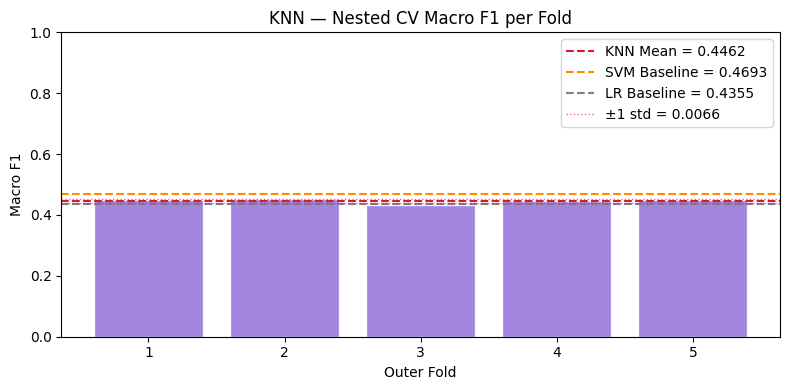

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
folds = list(range(1, 6))
ax.bar(folds, outer_scores, color='mediumpurple', edgecolor='white', alpha=0.85)
ax.axhline(np.mean(outer_scores), color='crimson', linestyle='--', linewidth=1.5,
           label=f'KNN Mean = {np.mean(outer_scores):.4f}')
ax.axhline(BASELINE_SVM, color='darkorange', linestyle='--', linewidth=1.5,
           label=f'SVM Baseline = {BASELINE_SVM:.4f}')
ax.axhline(BASELINE_LR, color='grey', linestyle='--', linewidth=1.5,
           label=f'LR Baseline = {BASELINE_LR:.4f}')
ax.axhline(np.mean(outer_scores) + np.std(outer_scores), color='crimson',
           linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(np.mean(outer_scores) - np.std(outer_scores), color='crimson',
           linestyle=':', linewidth=1, alpha=0.6,
           label=f'±1 std = {np.std(outer_scores):.4f}')
ax.set_xlabel('Outer Fold')
ax.set_ylabel('Macro F1')
ax.set_title('KNN — Nested CV Macro F1 per Fold')
ax.set_xticks(folds)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
print('Best hyperparameters across outer folds:')
param_counts = Counter([str(p) for p in best_params_log])
for params, count in param_counts.most_common():
    print(f'  {count:2d} fold(s): {params}')

Best hyperparameters across outer folds:
   3 fold(s): {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
   2 fold(s): {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


## Final Model

Re-run `GridSearchCV` on the **full training set**, then evaluate on the held-out test set **once**.

In [7]:
print('Fitting final model on full training set...\n')

final_gs = GridSearchCV(
    KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1),
    param_grid,
    cv=inner_cv, scoring='f1_macro',
    n_jobs=-1, refit=True
)
final_gs.fit(X_train, y_train)

print(f'Best params      : {final_gs.best_params_}')
print(f'Best inner CV F1 : {final_gs.best_score_:.4f}')

Fitting final model on full training set...

Best params      : {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best inner CV F1 : 0.4474


## Test Set Evaluation

> Evaluate on `test_multiclass.csv` **once only** — this is the final performance number.

In [8]:
final_model = final_gs.best_estimator_
y_pred_test = final_model.predict(X_test)

test_macro_f1 = f1_score(y_test, y_pred_test, average='macro')
print(f'Test set Macro F1 : {test_macro_f1:.4f}')
print(f'LR Baseline       : {BASELINE_LR:.4f}')
print(f'SVM Baseline      : {BASELINE_SVM:.4f}')
print(f'Improvement vs SVM: {test_macro_f1 - BASELINE_SVM:+.4f}\n')
print('Classification Report (Test Set):')
print(classification_report(y_test, y_pred_test, labels=CLASS_ORDER, target_names=CLASS_ORDER))

Test set Macro F1 : 0.4516
LR Baseline       : 0.4355
SVM Baseline      : 0.4693
Improvement vs SVM: -0.0177

Classification Report (Test Set):
              precision    recall  f1-score   support

        Good       0.71      0.84      0.77      7168
       Mixed       0.44      0.33      0.38      3208
         Bad       0.34      0.15      0.21       955

    accuracy                           0.64     11331
   macro avg       0.50      0.44      0.45     11331
weighted avg       0.60      0.64      0.61     11331



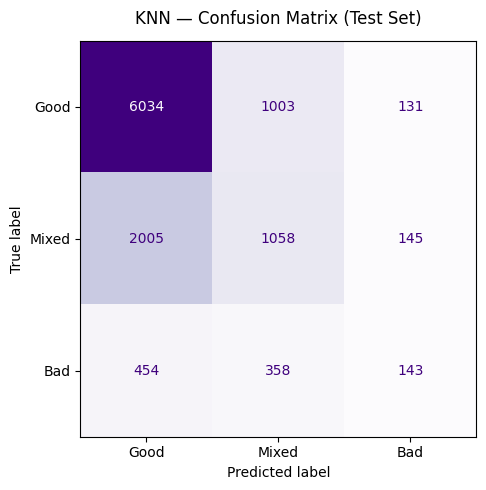

In [9]:
cm = confusion_matrix(y_test, y_pred_test, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('KNN — Confusion Matrix (Test Set)', pad=12)
plt.tight_layout()
plt.show()

## Feature Importance

KNN is a **non-parametric** model — it has no coefficients or feature importances.  
Instead, we show which features have the highest variance in the training set,  
since high-variance features dominate Euclidean/Manhattan distances and drive KNN decisions.

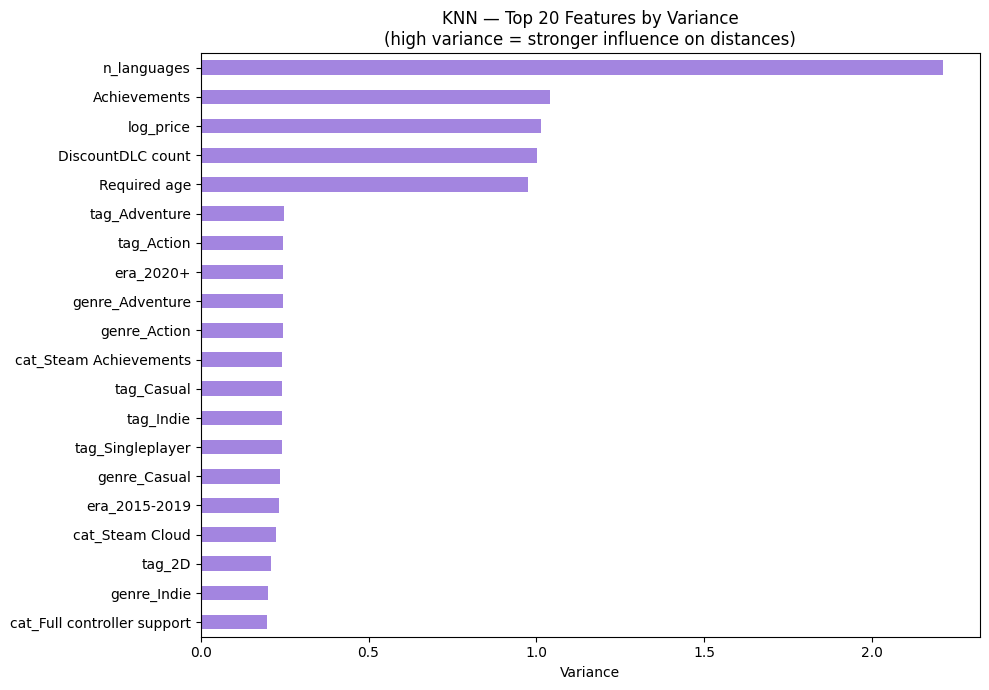


Top 10 highest-variance features:
  n_languages                               2.2116
  Achievements                              1.0420
  log_price                                 1.0135
  DiscountDLC count                         1.0020
  Required age                              0.9754
  tag_Adventure                             0.2476
  tag_Action                                0.2461
  era_2020+                                 0.2451
  genre_Adventure                           0.2448
  genre_Action                              0.2438


In [10]:
feature_variance = X_train.var().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
feature_variance.head(20).sort_values().plot(
    kind='barh', ax=ax, color='mediumpurple', alpha=0.85
)
ax.set_title('KNN — Top 20 Features by Variance\n(high variance = stronger influence on distances)', fontsize=12)
ax.set_xlabel('Variance')
plt.tight_layout()
plt.show()

print('\nTop 10 highest-variance features:')
for feat, var in feature_variance.head(10).items():
    print(f'  {feat:40s}  {var:.4f}')

## Results Summary

| Metric | Value |
|--------|-------|
| Nested CV Macro F1 (mean ± std) | — |
| Test set Macro F1 | — |
| Best params (nested CV) | — |
| Best params (final model) | — |
| vs LR Baseline (0.4355) | — |
| vs SVM Baseline (0.4693) | — |

**Per-class F1 (test set):**

| Class | Precision | Recall | F1 |
|-------|-----------|--------|----|
| Good  | — | — | — |
| Mixed | — | — | — |
| Bad   | — | — | — |

**Interpretation:**

> Fill in after running. Note: KNN cannot apply `class_weight` — if Bad/Mixed F1 is low,  
> this is expected and attributable to the majority-class dominance in neighbourhood voting.